<h1 style="text-align: center;">Fake News Detection Model</h1>

The goal of this project is to build a machine learning model that can classify news articles as real or fake.

Import Libraries and load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#load the dataset
df = pd.read_csv("fake_or_real_news.csv")

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
df.shape

(6335, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
df["label"].value_counts()

,count
label,
REAL,3171
FAKE,3164


EDA - Exploratory Data Analysis

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,0
text,0
label,0


In [ ]:
df["content"] = df["title"] + " " + df["text"]

In [ ]:
df.head()

,Unnamed: 0,title,text,label,content
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,You Can Smell Hillary’s Fear Daniel Greenfield...
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,Watch The Exact Moment Paul Ryan Committed Pol...
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,Kerry to go to Paris in gesture of sympathy U....
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,Bernie supporters on Twitter erupt in anger ag...
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,The Battle of New York: Why This Primary Matte...


In [ ]:
df["length"] = df["content"].apply(len)

df["length"].describe()

,length
count,6335.000000
mean,4773.528019
std,5091.586399
min,14.000000
25%,1804.500000
50%,3709.000000
75%,6254.500000
max,115448.000000


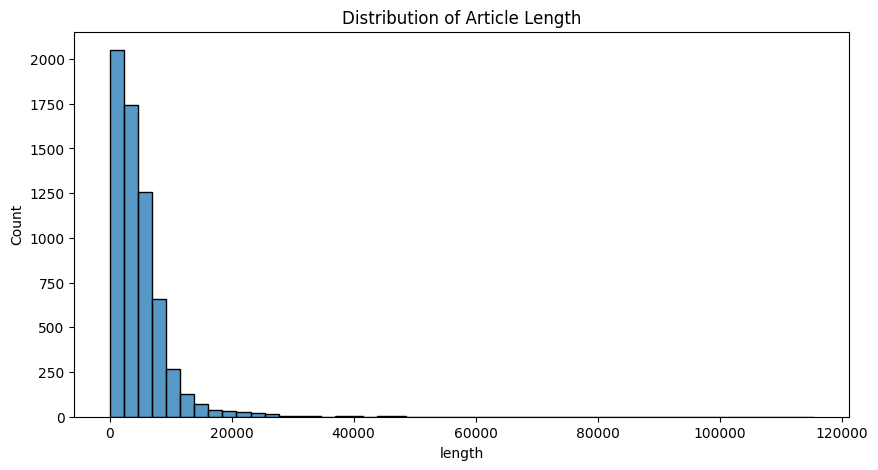

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["length"], bins=50)
plt.title("Distribution of Article Length")
plt.show()

Preprocessing

In [ ]:
#convert labels into binary values
df["label"] = df["label"].map({"REAL": 1, "FAKE": 0})

df["label"].value_counts()

,count
label,
1,3171
0,3164


In [ ]:
import re

#basic text cleaning function
def clean_text(text):
    text = text.lower()                     # lowercase
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text) # remove special characters
    text = re.sub(r"\s+", " ", text)        # remove extra spaces
    return text.strip()

In [ ]:
#apply cleaning
df["clean_text"] = df["content"].apply(clean_text)

In [ ]:
df.head()

,Unnamed: 0,title,text,label,content,length,clean_text
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",0,You Can Smell Hillary’s Fear Daniel Greenfield...,7547,you can smell hillarys fear daniel greenfield ...
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,0,Watch The Exact Moment Paul Ryan Committed Pol...,2732,watch the exact moment paul ryan committed pol...
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,1,Kerry to go to Paris in gesture of sympathy U....,2587,kerry to go to paris in gesture of sympathy us...
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0,Bernie supporters on Twitter erupt in anger ag...,2745,bernie supporters on twitter erupt in anger ag...
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,1,The Battle of New York: Why This Primary Matte...,1889,the battle of new york why this primary matter...


In [ ]:
from sklearn.model_selection import train_test_split

#features and labels
X = df["clean_text"]
y = df["label"]

#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 5068
Test size: 1267


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

#define vocabulary size
vocab_size = 10000

#create tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [ ]:
#convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

#define max length
max_length = 500

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding="post")

print(X_train_pad.shape)
print(X_test_pad.shape)

(5068, 500)
(1267, 500)


Modeling

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

#build the LSTM model for fake news classification
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the model
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
#train model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6575 - loss: 0.6253 - val_accuracy: 0.7308 - val_loss: 0.5439
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7780 - loss: 0.4735 - val_accuracy: 0.7751 - val_loss: 0.4786
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8147 - loss: 0.3820 - val_accuracy: 0.7702 - val_loss: 0.4955
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8437 - loss: 0.3116 - val_accuracy: 0.7643 - val_loss: 0.5317
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8567 - loss: 0.2846 - val_accuracy: 0.7781 - val_loss: 0.5876


In [ ]:
#evaluate on test set
test_loss, test_acc = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", test_acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7552 - loss: 0.6568
Test Accuracy: 0.7640094757080078


In [ ]:
#Predict probabilities on the test set
y_pred_probs = model.predict(X_test_pad)

#convert probabilities into binary predictions
y_pred = (y_pred_probs > 0.5).astype("int32")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#create confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[567,  66],
       [233, 401]])

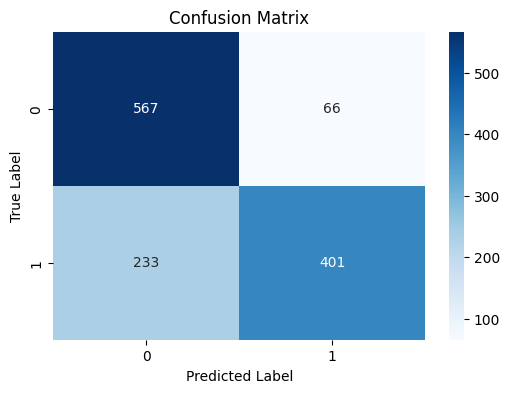

In [ ]:
#Plot cm
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
#print precision, recall, and f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.90      0.79       633
           1       0.86      0.63      0.73       634

    accuracy                           0.76      1267
   macro avg       0.78      0.76      0.76      1267
weighted avg       0.78      0.76      0.76      1267



## Conclusion

The final model achieved:

- Training Accuracy: ~85%
- Validation Accuracy: ~78%
- Test Accuracy: ~76%

The model performed well overall and demonstrated solid generalization on unseen data.

The confusion matrix shows that the model detects fake news very effectively, but struggles more with real news classification. This is expected since real news articles often have more diverse writing styles.

In [ ]:
#save the trained model
model.save("fake_news_lstm_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import pickle

#save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [ ]:
import os

os.listdir()

['.config',
 'fake_news_lstm_model.keras',
 'tokenizer.pkl',
 'fake_or_real_news.csv',
 'sample_data']